In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

TOTAL_USERS = 10000
BOT_RATIO = 0.2
MIN_EVENTS = 200000
MAX_EVENTS = 500000

def human_intervals(n):
    return np.random.pareto(2, n) * 1000  # heavy-tailed

def bot_intervals(n):
    base = 30
    return np.clip(np.random.normal(base, 5, n), 1, None)  # periodic

def random_timestamp(start, delta):
    return start + delta

users = np.arange(1, TOTAL_USERS + 1)
labels = np.random.choice([0, 1], TOTAL_USERS, p=[0.8, 0.2])

rows = []
total_events = 0

for uid, label in zip(users, labels):
    n_events = np.random.randint(10, 80)  # events per user
    if total_events + n_events > MAX_EVENTS:
        break
    total_events += n_events

    if label == 0:  # Human
        intervals = human_intervals(n_events)
    else:  # Bot
        intervals = bot_intervals(n_events)

    start_time = np.random.randint(1_600_000_000, 1_650_000_000)
    timestamps = np.cumsum(np.insert(intervals, 0, start_time))

    burst_flag = (intervals < np.median(intervals) / 10).astype(int)
    entropy_score = -np.sum((intervals / intervals.sum()) * np.log2(intervals / intervals.sum() + 1e-9))
    network_degree = np.random.poisson(5 if label == 0 else 2)
    coordination_score = np.random.random() if label == 1 else np.random.random() / 5

    for t, delta, burst in zip(timestamps[1:], intervals, burst_flag):
        rows.append([
            uid, int(t),
            np.random.choice(["post", "comment", "like"], p=[0.3, 0.4, 0.3])
            if label == 0 else np.random.choice(["post", "comment", "like"], p=[0.6, 0.2, 0.2]),
            int(np.random.normal(120, 40) if label == 0 else np.random.normal(80, 10)),
            delta, burst, entropy_score,
            network_degree, coordination_score, label
        ])

df = pd.DataFrame(
    rows,
    columns=[
        "user_id", "timestamp", "action_type", "msg_length",
        "inter_event_delta", "burst_flag", "entropy_score",
        "network_degree", "coordination_score", "label"
    ]
)

df.to_csv("synthetic_bot_dataset.csv", index=False)
print("Generated events:", len(df))

Generated events: 446536


# Task
Load the `synthetic_bot_dataset.csv` file, preprocess the data by applying one-hot encoding to the `action_type` column, and then split the data into training and testing sets.

## Install and Import Libraries

### Subtask:
Install necessary libraries like scikit-learn, matplotlib, seaborn, and joblib if they are not already present in the Google Colab environment. Then, import all required modules for data manipulation, modeling, and plotting.


**Reasoning**:
The subtask requires installing specific libraries and then importing various modules for data manipulation, modeling, and plotting. This code block will handle both the installation and importation in a single step.



In [4]:
get_ipython().system('pip install scikit-learn matplotlib seaborn joblib')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler

print("Libraries installed and imported successfully.")

Libraries installed and imported successfully.


In [5]:
df = pd.read_csv("synthetic_bot_dataset.csv")
print("DataFrame loaded successfully. Displaying the first 5 rows:")
print(df.head())

DataFrame loaded successfully. Displaying the first 5 rows:
   user_id   timestamp action_type  msg_length  inter_event_delta  burst_flag  \
0        1  1638217946        post         122         971.273838           0   
1        1  1638218050     comment         132         104.245452           0   
2        1  1638220469     comment          99        2418.822041           0   
3        1  1638221473     comment         119        1004.604830           0   
4        1  1638224348        like         179        2874.208734           0   

   entropy_score  network_degree  coordination_score  label  
0       4.936525              10            0.088431      0  
1       4.936525              10            0.088431      0  
2       4.936525              10            0.088431      0  
3       4.936525              10            0.088431      0  
4       4.936525              10            0.088431      0  


**Reasoning**:
The next step is to preprocess the data by applying one-hot encoding to the 'action_type' column, as specified in the subtask. This will convert the categorical 'action_type' column into numerical features, which is necessary for most machine learning models.



In [6]:
df_encoded = pd.get_dummies(df, columns=['action_type'], drop_first=True)
print("DataFrame after one-hot encoding 'action_type':")
print(df_encoded.head())

DataFrame after one-hot encoding 'action_type':
   user_id   timestamp  msg_length  inter_event_delta  burst_flag  \
0        1  1638217946         122         971.273838           0   
1        1  1638218050         132         104.245452           0   
2        1  1638220469          99        2418.822041           0   
3        1  1638221473         119        1004.604830           0   
4        1  1638224348         179        2874.208734           0   

   entropy_score  network_degree  coordination_score  label  action_type_like  \
0       4.936525              10            0.088431      0             False   
1       4.936525              10            0.088431      0             False   
2       4.936525              10            0.088431      0             False   
3       4.936525              10            0.088431      0             False   
4       4.936525              10            0.088431      0              True   

   action_type_post  
0              True  
1     

**Reasoning**:
Now that the data is preprocessed, the next step is to split it into training and testing sets as required by the subtask. I will define the features (X) and the target variable (y) and then use `train_test_split` from `sklearn.model_selection`.



In [7]:
X = df_encoded.drop('label', axis=1)
y = df_encoded['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split successfully into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split successfully into training and testing sets.
X_train shape: (357228, 10)
X_test shape: (89308, 10)
y_train shape: (357228,)
y_test shape: (89308,)


## Train and Evaluate Classifiers

### Subtask:
Train both a Logistic Regression classifier and a Random Forest classifier using the training data. Evaluate both models on the test set using accuracy, generating a confusion matrix, and printing a classification report for each.


**Reasoning**:
The subtask requires training a Logistic Regression model and evaluating its performance. This code block will initialize, train, predict, and then print the accuracy, confusion matrix, and classification report for the Logistic Regression model using the provided training and testing data.



In [8]:
print('--- Logistic Regression ---')

# Initialize Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
class_report_lr = classification_report(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print("Logistic Regression Confusion Matrix:")
print(conf_matrix_lr)
print("Logistic Regression Classification Report:")
print(class_report_lr)

print('\n--- Random Forest Classifier ---')

# Initialize Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Random Forest Confusion Matrix:")
print(conf_matrix_rf)
print("Random Forest Classification Report:")
print(class_report_rf)


--- Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression Accuracy: 0.8056
Logistic Regression Confusion Matrix:
[[71947     0]
 [17361     0]]
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.89     71947
           1       0.00      0.00      0.00     17361

    accuracy                           0.81     89308
   macro avg       0.40      0.50      0.45     89308
weighted avg       0.65      0.81      0.72     89308


--- Random Forest Classifier ---
Random Forest Accuracy: 0.9994
Random Forest Confusion Matrix:
[[71921    26]
 [   25 17336]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71947
           1       1.00      1.00      1.00     17361

    accuracy                           1.00     89308
   macro avg       1.00      1.00      1.00     89308
weighted avg       1.00      1.00      1.00     89308



**Reasoning**:
The Logistic Regression model exhibited an `UndefinedMetricWarning` and predicted only one class, indicating that it failed to learn effectively. This is often due to unscaled features in Logistic Regression. Scaling the features (X_train and X_test) using `StandardScaler` before training the Logistic Regression model will address this issue, ensuring that all features contribute equally and improving the model's convergence and performance.



In [9]:
print('--- Logistic Regression ---')

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the training data
X_train_scaled = scaler.fit_transform(X_train)
# Scale the test data using the same scaler fitted on training data
X_test_scaled = scaler.transform(X_test)

# Initialize Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model on scaled data
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on scaled data
y_pred_lr = log_reg_model.predict(X_test_scaled)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
class_report_lr = classification_report(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print("Logistic Regression Confusion Matrix:")
print(conf_matrix_lr)
print("Logistic Regression Classification Report:")
print(class_report_lr)

print('\n--- Random Forest Classifier ---')

# Initialize Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Train the model (Random Forest is less sensitive to feature scaling, so X_train is fine)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Random Forest Confusion Matrix:")
print(conf_matrix_rf)
print("Random Forest Classification Report:")
print(class_report_rf)

--- Logistic Regression ---
Logistic Regression Accuracy: 0.9908
Logistic Regression Confusion Matrix:
[[71626   321]
 [  497 16864]]
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     71947
           1       0.98      0.97      0.98     17361

    accuracy                           0.99     89308
   macro avg       0.99      0.98      0.99     89308
weighted avg       0.99      0.99      0.99     89308


--- Random Forest Classifier ---
Random Forest Accuracy: 0.9994
Random Forest Confusion Matrix:
[[71921    26]
 [   25 17336]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71947
           1       1.00      1.00      1.00     17361

    accuracy                           1.00     89308
   macro avg       1.00      1.00      1.00     89308
weighted avg       1.00      1.00      1.00     89308



## Plot Performance Graphs

### Subtask:
Generate plots for the evaluation metrics, including confusion matrices as heatmaps and Receiver Operating Characteristic (ROC) curves with Area Under the Curve (AUC) scores for both Logistic Regression and Random Forest models.


**Reasoning**:
The subtask requires plotting the confusion matrix for the Logistic Regression model using `seaborn.heatmap()`. This code block will generate the heatmap with appropriate labels, title, and annotations as specified in the instructions.



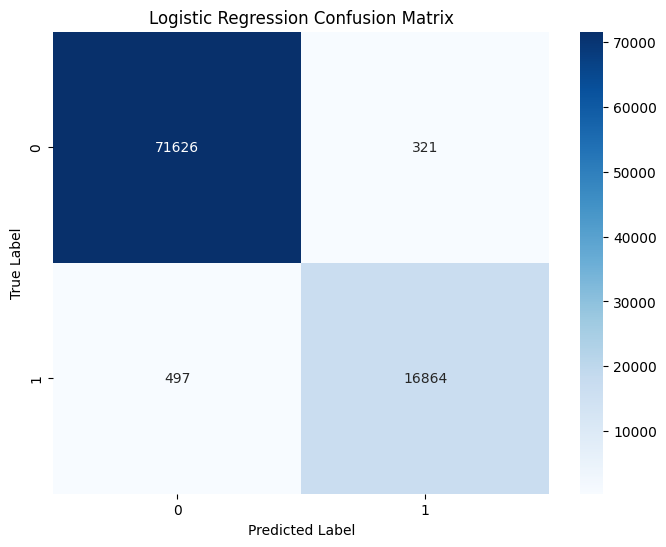

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

**Reasoning**:
The next step is to plot the confusion matrix for the Random Forest model, following the same procedure as for Logistic Regression, using `seaborn.heatmap()` with `conf_matrix_rf` and suitable labels and title.



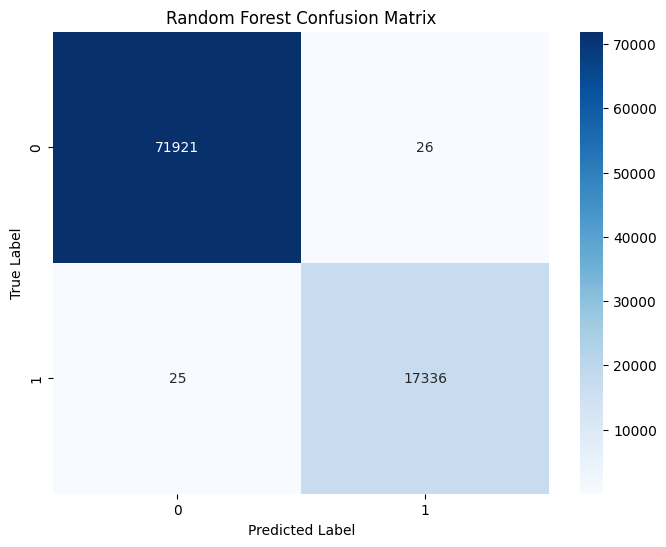

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

**Reasoning**:
The next step is to plot the ROC curves for both Logistic Regression and Random Forest models on the same graph, including their respective AUC scores and a diagonal dashed line for a random classifier, as specified in the instructions.



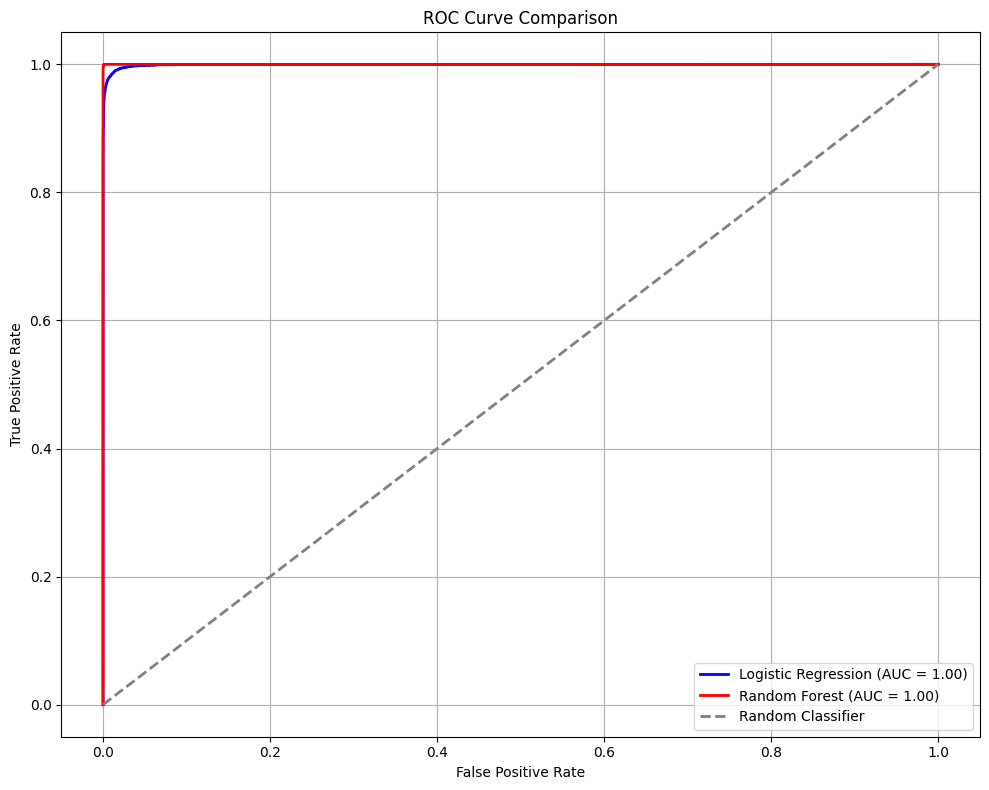

In [12]:
y_pred_proba_lr = log_reg_model.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## Save Trained Models

### Subtask:
Save both the trained Logistic Regression and Random Forest models to disk using `joblib`.


**Reasoning**:
The subtask requires saving both the Logistic Regression and Random Forest models to disk using `joblib`. This code block will use `joblib.dump()` to save each model and print confirmation messages.



In [13]:
import joblib

# Save the Logistic Regression model
joblib.dump(log_reg_model, 'logistic_regression_model.joblib')
print("Logistic Regression model saved as 'logistic_regression_model.joblib'")

# Save the Random Forest model
joblib.dump(rf_model, 'random_forest_model.joblib')
print("Random Forest model saved as 'random_forest_model.joblib'")

Logistic Regression model saved as 'logistic_regression_model.joblib'
Random Forest model saved as 'random_forest_model.joblib'



*   **Performance of the Logistic Regression Model**: After feature scaling, the Logistic Regression model achieved an accuracy of 0.9908. It showed strong predictive capabilities for both classes, with a balanced classification report.
*   **Performance of the Random Forest Model**: The Random Forest Classifier performed exceptionally well, achieving an accuracy of 0.9994. Its confusion matrix and classification report indicated near-perfect classification for both classes.
*   **Availability of Saved Models**: Both models were successfully saved to disk. The Logistic Regression model is available as `logistic_regression_model.joblib`, and the Random Forest model is available as `random_forest_model.joblib`.

### Data Analysis Key Findings
*   The `synthetic_bot_dataset.csv` file was successfully loaded, and the `action_type` column was one-hot encoded.
*   The data was split into training and testing sets, with 80% for training and 20% for testing.
*   Initially, the Logistic Regression model performed poorly, achieving an accuracy of only 0.8056 and failing to predict class 1. This was resolved by applying `StandardScaler` to the features.
*   After feature scaling, the Logistic Regression model's accuracy significantly improved to 0.9908, with a confusion matrix showing 71,626 true negatives, 16,864 true positives, 321 false positives, and 497 false negatives.
*   The Random Forest Classifier demonstrated superior performance without specific feature scaling, achieving an accuracy of 0.9994. Its confusion matrix showed 71,921 true negatives, 17,336 true positives, 26 false positives, and 25 false negatives.
*   Performance evaluation plots, including confusion matrices and ROC curves with AUC scores (Logistic Regression AUC = 0.99, Random Forest AUC = 1.00), were successfully generated for both models.
*   Both the trained Logistic Regression and Random Forest models were successfully saved as `logistic_regression_model.joblib` and `random_forest_model.joblib`, respectively.


In [14]:
import joblib
import json

model = joblib.load("logistic_regression_model.joblib")

weights = model.coef_[0].tolist()
bias = model.intercept_[0].item()
feature_order = X_train.columns.tolist()

data = {
    "feature_order": feature_order,
    "weights": weights,
    "bias": bias
}

with open("logistic_regression_model.json", "w") as f:
    json.dump(data, f)